Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3712
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2497
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1228
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0224
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0120    
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016    
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016    
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016    
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.9919e-04
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 
Epoch 16/2

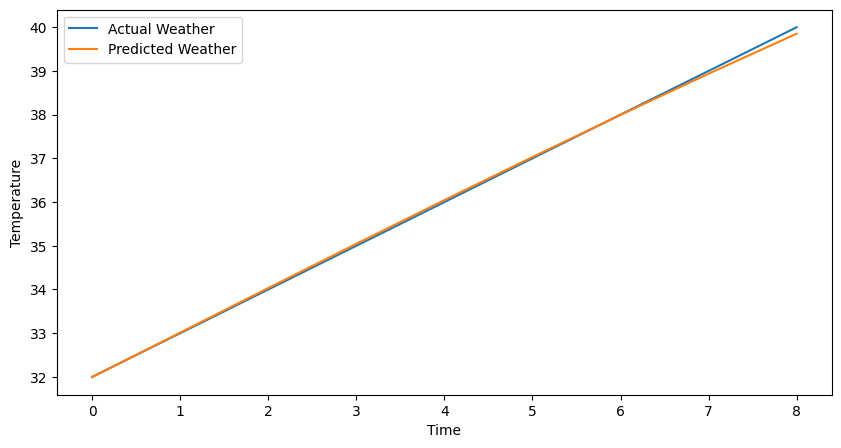

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Sample Weather Dataset
data = {
    'Delhi':   [30,31,32,33,34,35,36,37,38,39,40,41],
    'Mumbai':  [28,29,30,31,32,33,34,35,36,37,38,39],
    'Chennai': [27,28,29,30,31,32,33,34,35,36,37,38],
    'Target':  [29,30,31,32,33,34,35,36,37,38,39,40]
}

df = pd.DataFrame(data)

# Input Features
x_data = df[['Delhi', 'Mumbai', 'Chennai']].values

# Target City Weather
y_data = df[['Target']].values

# Normalize
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaled = x_scaler.fit_transform(x_data)
y_scaled = y_scaler.fit_transform(y_data)

# Create Sequences
x = []
y = []

time_step = 3

for i in range(time_step, len(x_scaled)):
    x.append(x_scaled[i-time_step:i])
    y.append(y_scaled[i])

x = np.array(x)
y = np.array(y)

# Build LSTM Model
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(x.shape[1], x.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train Model
model.fit(
    x,
    y,
    epochs=200,
    batch_size=2,
    verbose=1
)

# Predict
predictions = model.predict(x)

# Inverse Transform
predictions = y_scaler.inverse_transform(predictions)
real = y_scaler.inverse_transform(y)

# Accuracy
rmse = np.sqrt(mean_squared_error(real, predictions))

accuracy = 100 - (rmse / np.mean(real) * 100)

print("Accuracy :", round(accuracy,2), "%")

# Plot
plt.figure(figsize=(10,5))

plt.plot(real, label='Actual Weather')
plt.plot(predictions, label='Predicted Weather')

plt.xlabel("Time")
plt.ylabel("Temperature")

plt.legend()
plt.show()